In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
df = pd.read_csv('avocado_clean.csv')

In [51]:
df.head()

df = df.drop(columns = ['Date'], axis=1)

df.head()

,AveragePrice,Total Volume,4046,4225,Total Bags,Small Bags,type,region
0,1.33,64236.62,1036.74,54454.85,8696.87,8603.62,conventional,Albany
1,1.35,54876.98,674.28,44638.81,9505.56,9408.07,conventional,Albany
2,0.93,118220.22,794.70,109149.67,8145.35,8042.21,conventional,Albany
3,1.08,78992.15,1132.00,71976.41,5811.16,5677.40,conventional,Albany
4,1.28,51039.60,941.48,43838.39,6183.95,5986.26,conventional,Albany


# Clasificación de columna 'type'. Clasifando entre aguacates orgánicos o convencionales

In [52]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder


df_dummies = pd.get_dummies(df, columns= ['region'])


encoder = LabelEncoder()
df_dummies['type'] = encoder.fit_transform(df_dummies['type'])


y = df_dummies['type']
X = df_dummies.drop(columns = ['type'], axis=1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


param_grid = {'n_neighbors': range(1, 21)}

# Modelo base
knn = KNeighborsClassifier()

# Grid search con validación cruzada de 5 folds
grid = GridSearchCV(knn, param_grid, cv=5)
grid.fit(X_train, y_train)


# Mejor k encontrado
print("Mejor número de vecinos:", grid.best_params_['n_neighbors'])
print("Mejor exactitud en validación:", grid.best_score_)


Mejor número de vecinos: 1
Mejor exactitud en validación: 0.9651663405088062


Se observa que solo basta un vecino para clasificar con la mayor exactitud posible el modelo. Esto es un resultado muy atípico, pero muy probablemente se deba a que, por lo general, los valores de todas la métricas para aguacates orgánicos dan valores muy bajos y diferenciados en comparación de los aguacates convencionales. Por ejemplo, observe la siguiente imagen

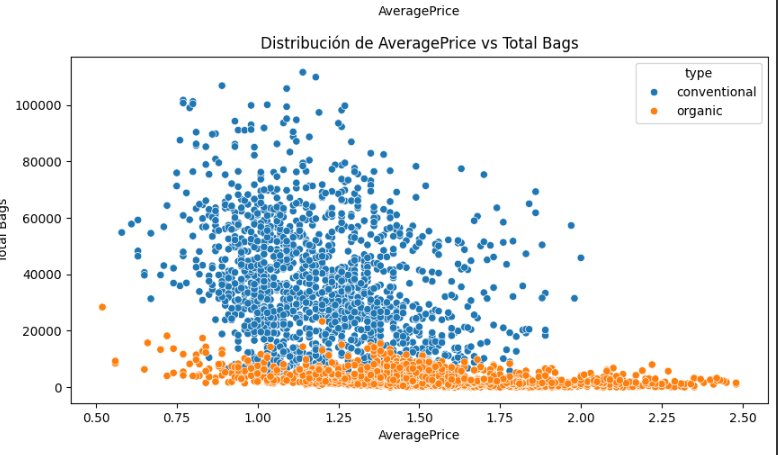

Muy probablemente tenga más sentido, y claramente es más relevante, realizar un modelo de KNN para intentar predecir la region de la que proviene cada aguacate, aunque al ser 53 regiones diferentes muy probablemente se obtengan resultados no deseados.

# Clasificación de columna 'region': Clasificando entre la correspondencia de cada estadística con sus distintas regiones

In [53]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder


df_dummies = pd.get_dummies(df, columns= ['type'])

encoder = LabelEncoder()
df_dummies['region'] = encoder.fit_transform(df_dummies['region'])


y = df_dummies['region']
X = df_dummies.drop(columns = ['region'], axis=1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


param_grid = {'n_neighbors': range(1, 15)}

# Modelo base
knn = KNeighborsClassifier()

# Grid search con validación cruzada de 5 folds
grid = GridSearchCV(knn, param_grid, cv=3)
grid.fit(X_train, y_train)


# Mejor k encontrado
print("Mejor número de vecinos:", grid.best_params_['n_neighbors'])
print("Mejor exactitud en validación:", grid.best_score_)


Mejor número de vecinos: 1
Mejor exactitud en validación: 0.536986301369863


De nuevo, se obtiene que con un vecino cercano se obtiene el mejor resultado, lo cual vuelve a ser raro. De hecho, la exactitud de la validación es muy mala, hay un 50% de probabilidad de que el modelo arroje el resultado correcto. Aun así, considerando que debe clasificar entre 53 regiones, se puede observar que por lo menos no hace una clasificación completamente al azar. Esto implica que la información utilizada sí permite conocer información sobre el tipo de region con KNN.